# Continuous-time Successive Convexification

## Minimum-time problem

Here the horizon is fixed in normalized time `tau in [0,1]`, while physical time is optimized through `s = dt/dtau`.

```text
xi  = [px, py, vx, vy, path_violation, physical_time]
eta = [ax, ay, s]
objective = xi_time at the final knot
```


### Minimum-time imports


In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from typing import List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

from pydrake.solvers import MathematicalProgram, MosekSolver, Solve
from pydrake.systems.analysis import Simulator
from pydrake.systems.framework import BasicVector, DiagramBuilder, LeafSystem
from pydrake.systems.primitives import LogVectorOutput


### Minimum-time problem data


In [2]:
@dataclass
class MinimumTimeDoubleIntegratorProblem:
    """All parameters for the 2D double-integrator minimum-time problem."""

    nx: int = 4
    nu: int = 2
    N: int = 10

    x0hat: np.ndarray = field(default_factory=lambda: np.zeros(4))
    xfhat: np.ndarray = field(default_factory=lambda: np.array([10.0, 10.0, 0.0, 0.0]))

    tmin: float = 5.0
    tmax: float = 20.0

    umax: np.ndarray = field(default_factory=lambda: np.ones(2))
    umin: np.ndarray = field(default_factory=lambda: -np.ones(2))
    velmax: float = 3.0
    obst_cen: np.ndarray = field(default_factory=lambda: np.array([5.0, 4.5]))
    obst_rad: float = 3.0

    maxiter: int = 300
    eps: float = 5e-3
    gam: float = 1e2
    rho: float = 1e-2
    eps_path: float = 1e-6

    ode_rtol: float = 1e-3
    ode_atol: float = 1e-6

    def __post_init__(self) -> None:
        self.nxi = self.nx + 2
        self.neta = self.nu + 1
        self.taustamps = np.linspace(0.0, 1.0, self.N)
        self.dtau = 1.0 / (self.N - 1)

        self.Ac = np.block(
            [
                [np.zeros((2, 2)), np.eye(2)],
                [np.zeros((2, 2)), np.zeros((2, 2))],
            ]
        )
        self.Bc = np.block([[np.zeros((2, 2))], [np.eye(2)]])
        self.xbar2pos = np.block([np.eye(2), np.zeros((2, 2)), np.zeros((2, 2))])
        self.xbar2vel = np.block([np.zeros((2, 2)), np.eye(2), np.zeros((2, 2))])

        self.x0hat = np.asarray(self.x0hat, dtype=float).reshape(self.nx)
        self.xfhat = np.asarray(self.xfhat, dtype=float).reshape(self.nx)
        self.umax = np.asarray(self.umax, dtype=float).reshape(self.nu)
        self.umin = np.asarray(self.umin, dtype=float).reshape(self.nu)
        self.obst_cen = np.asarray(self.obst_cen, dtype=float).reshape(2)
        self.rho = 1.0 / self.gam if self.rho is None else float(self.rho)


@dataclass
class ProxLinearIterationStats:
    iteration: int
    final_time_state: float
    physical_time_from_eta: float
    slack: float
    step: float
    solver_name: str
    success: bool


@dataclass
class MinimumTimePlan:
    xi_nodes: np.ndarray
    eta_intervals: np.ndarray
    tau_grid: np.ndarray
    physical_time_from_eta: np.ndarray
    history: List[ProxLinearIterationStats]

    @property
    def x_nodes(self) -> np.ndarray:
        return self.xi_nodes[:4, :]

    @property
    def violation_nodes(self) -> np.ndarray:
        return self.xi_nodes[4, :]

    @property
    def time_nodes_from_state(self) -> np.ndarray:
        return self.xi_nodes[5, :]

    @property
    def u_intervals(self) -> np.ndarray:
        return self.eta_intervals[:2, :]

    @property
    def s_intervals(self) -> np.ndarray:
        return self.eta_intervals[2, :]

    @property
    def final_time(self) -> float:
        return float(self.physical_time_from_eta[-1])


@dataclass
class RolloutLog:
    t: np.ndarray
    x: np.ndarray


### Minimum-time Drake Systems: plant and feedforward controller


In [3]:
class DoubleIntegrator2D(LeafSystem):
    """Physical plant only: Ax Bu
    """

    def __init__(self, problem: MinimumTimeDoubleIntegratorProblem):
        super().__init__()
        self._problem = problem
        self.DeclareVectorInputPort("u", BasicVector(problem.nu))
        self.DeclareContinuousState(problem.nx)
        self.DeclareVectorOutputPort("x", BasicVector(problem.nx), self._calc_output)

    def _calc_output(self, context, output) -> None:
        x = context.get_continuous_state_vector().CopyToVector()
        output.SetFromVector(x)

    def DoCalcTimeDerivatives(self, context, derivatives) -> None:
        x = context.get_continuous_state_vector().CopyToVector()
        u = self.get_input_port(0).Eval(context)
        xdot = self._problem.Ac @ x + self._problem.Bc @ u
        derivatives.get_mutable_vector().SetFromVector(xdot)


class PiecewiseConstantFeedforwardController(LeafSystem):
    """A Drake System wrapping the optimized piecewise-constant u(t)."""

    def __init__(self, break_times: np.ndarray, u_intervals: np.ndarray):
        super().__init__()
        self._break_times = np.asarray(break_times, dtype=float).reshape(-1)
        self._u_intervals = np.asarray(u_intervals, dtype=float)
        assert self._u_intervals.shape[1] == len(self._break_times) - 1
        self.DeclareVectorOutputPort(
            "u", BasicVector(self._u_intervals.shape[0]), self._calc_output
        )

    def _calc_output(self, context, output) -> None:
        t = context.get_time()
        k = int(np.searchsorted(self._break_times, t, side="right") - 1)
        k = int(np.clip(k, 0, self._u_intervals.shape[1] - 1))
        output.SetFromVector(self._u_intervals[:, k])


### Minimum-time augmented dynamics and flow-map linearization


In [4]:
# Augmented dynamics and exact flow-map linearization
class AugmentedMinimumTimeDynamics:
    """Augmented tau-dynamics used by the prox-linear planner.

    xi  = [px, py, vx, vy, path_violation_accumulator, physical_time]
    eta = [ax, ay, s]

    dxi/dtau = s * [Ac x + Bc u; path_violation(x); 1]
    """

    def __init__(self, problem: MinimumTimeDoubleIntegratorProblem):
        self.p = problem

    def path_violation(self, xi: np.ndarray) -> float:
        vel = self.p.xbar2vel @ xi
        pos = self.p.xbar2pos @ xi
        speed_violation = float(np.dot(vel, vel) / self.p.velmax**2 - 1.0)
        obstacle_violation = float(
            1.0 - np.dot(pos - self.p.obst_cen, pos - self.p.obst_cen) / self.p.obst_rad**2
        )
        return 0.5 * max(speed_violation, 0.0) ** 2 + 0.5 * max(obstacle_violation, 0.0) ** 2

    def fbar(self, xi: np.ndarray, eta: np.ndarray) -> np.ndarray:
        x = xi[: self.p.nx]
        u = eta[: self.p.nu]
        s = float(eta[self.p.nu])
        xdot = self.p.Ac @ x + self.p.Bc @ u
        g = self.path_violation(xi)
        return s * np.concatenate([xdot, np.array([g, 1.0])])

    def continuous_jacobians(self, xi: np.ndarray, eta: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """Return dfbar/dxi and dfbar/deta.
        """

        x = xi[: self.p.nx]
        u = eta[: self.p.nu]
        s = float(eta[self.p.nu])

        vel = self.p.xbar2vel @ xi
        pos = self.p.xbar2pos @ xi
        speed_hinge_arg = np.dot(vel, vel) / self.p.velmax**2 - 1.0
        obstacle_hinge_arg = (
            1.0 - np.dot(pos - self.p.obst_cen, pos - self.p.obst_cen) / self.p.obst_rad**2
        )

        speed_row = (
            (speed_hinge_arg > 0.0)
            * (1.0 / self.p.velmax**2)
            * (vel.reshape(1, 2) @ self.p.xbar2vel)
        )
        obstacle_row = (
            (obstacle_hinge_arg > 0.0)
            * (-(1.0 / self.p.obst_rad**2))
            * ((pos - self.p.obst_cen).reshape(1, 2) @ self.p.xbar2pos)
        )
        violation_row = speed_row + obstacle_row

        top = np.hstack([self.p.Ac, np.zeros((self.p.nx, 2))])
        bottom = np.zeros((1, self.p.nxi))
        df_dxi = s * np.vstack([top, violation_row, bottom])

        g = self.path_violation(xi)
        df_deta = np.vstack(
            [
                np.hstack([s * self.p.Bc, (self.p.Ac @ x + self.p.Bc @ u).reshape(self.p.nx, 1)]),
                np.array([[0.0, 0.0, g]]),
                np.array([[0.0, 0.0, 1.0]]),
            ]
        )
        return df_dxi, df_deta


class FlowMapLinearizer:
    """Compute xi_{k+1} = F_k(xi_k, eta_k) and its Jacobians.
    """

    def __init__(self, problem: MinimumTimeDoubleIntegratorProblem):
        self.p = problem
        self.dyn = AugmentedMinimumTimeDynamics(problem)

    def _pack(self, eta: np.ndarray, xi: np.ndarray, Phi_x: np.ndarray, Phi_eta: np.ndarray) -> np.ndarray:
        return np.concatenate(
            [
                eta.reshape(-1),
                xi.reshape(-1),
                Phi_x.reshape(-1, order="F"),
                Phi_eta.reshape(-1, order="F"),
            ]
        )

    def _unpack(self, y: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        p = self.p
        i0 = 0
        i1 = p.neta
        i2 = i1 + p.nxi
        i3 = i2 + p.nxi * p.nxi
        i4 = i3 + p.nxi * p.neta
        eta = y[i0:i1]
        xi = y[i1:i2]
        Phi_x = y[i2:i3].reshape((p.nxi, p.nxi), order="F")
        Phi_eta = y[i3:i4].reshape((p.nxi, p.neta), order="F")
        return eta, xi, Phi_x, Phi_eta

    def _ode(self, _tau: float, y: np.ndarray) -> np.ndarray:
        eta, xi, Phi_x, Phi_eta = self._unpack(y)
        df_dxi, df_deta = self.dyn.continuous_jacobians(xi, eta)
        eta_dot = np.zeros(self.p.neta)
        xi_dot = self.dyn.fbar(xi, eta)
        Phi_x_dot = df_dxi @ Phi_x
        Phi_eta_dot = df_dxi @ Phi_eta + df_deta
        return self._pack(eta_dot, xi_dot, Phi_x_dot, Phi_eta_dot)

    def linearize_interval(
        self, xi_nom: np.ndarray, eta_nom: np.ndarray, tau0: float, tau1: float
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        p = self.p
        y0 = self._pack(
            eta_nom,
            xi_nom,
            np.eye(p.nxi),
            np.zeros((p.nxi, p.neta)),
        )
        sol = solve_ivp(
            self._ode,
            (float(tau0), float(tau1)),
            y0,
            method="RK45",
            rtol=p.ode_rtol,
            atol=p.ode_atol,
        )
        if not sol.success:
            raise RuntimeError(f"Flow-map integration failed: {sol.message}")

        eta_end, xi_next, A, B = self._unpack(sol.y[:, -1])
        del eta_end
        c = xi_next - A @ xi_nom - B @ eta_nom
        return xi_next, A, B, c


### Minimum-time prox-linear planner


In [5]:
# optimizer
class ProxLinearMinimumTimePlanner:
    """Offline prox-linear trajectory optimizer.

    This class is not a LeafSystem.  It solves for a plan before
    simulation.  The resulting plan is then wrapped as a feedforward controller.
    """

    def __init__(
        self,
        problem: MinimumTimeDoubleIntegratorProblem,
        random_seed: Optional[int] = None,
        verbose: bool = True,
    ):
        self.p = problem
        self.random_seed = random_seed
        self.verbose = verbose
        self.linearizer = FlowMapLinearizer(problem)

    def _initialize_nominal(self) -> Tuple[np.ndarray, np.ndarray]:
        p = self.p
        rng = np.random.default_rng(self.random_seed)

        # xi_tilde = rand(nx+2, N), eta_tilde = rand(nu+1, N-1).
        xi_tilde = rng.random((p.nxi, p.N))
        eta_tilde = rng.random((p.neta, p.N - 1))

        # structured initialization:
        # xi_tilde = np.zeros((p.nxi, p.N))
        # alpha = np.linspace(0.0, 1.0, p.N)
        # for k, a in enumerate(alpha):
        #     xi_tilde[: p.nx, k] = (1.0 - a) * p.x0hat + a * p.xfhat
        # eta_tilde = np.zeros((p.neta, p.N - 1))
        # eta_tilde[p.nu, :] = 0.5 * (p.tmin + p.tmax)

        return xi_tilde, eta_tilde

    def _linearize_all(self, xi_tilde: np.ndarray, eta_tilde: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        p = self.p
        A = np.zeros((p.nxi, p.nxi, p.N - 1))
        B = np.zeros((p.nxi, p.neta, p.N - 1))
        c = np.zeros((p.nxi, p.N - 1))
        for k in range(p.N - 1):
            _, A[:, :, k], B[:, :, k], c[:, k] = self.linearizer.linearize_interval(
                xi_tilde[:, k], eta_tilde[:, k], p.taustamps[k], p.taustamps[k + 1]
            )
        return A, B, c

    @staticmethod
    def _solver_name(result) -> str:
        try:
            return result.get_solver_id().name()
        except Exception:
            return "unknown"

    def _solve_subproblem(
        self, xi_tilde: np.ndarray, eta_tilde: np.ndarray, A: np.ndarray, B: np.ndarray, c: np.ndarray
    ):
        p = self.p
        prog = MathematicalProgram()

        Xi = prog.NewContinuousVariables(p.nxi, p.N, "xi")
        Eta = prog.NewContinuousVariables(p.neta, p.N - 1, "eta")
        q = prog.NewContinuousVariables(p.nxi, p.N - 1, "q")
        r = prog.NewContinuousVariables(p.nxi, p.N - 1, "r")

        # Boundary conditions
        prog.AddLinearEqualityConstraint(
            Xi[:, 0], np.concatenate([p.x0hat, np.zeros(2)])
        )
        prog.AddLinearEqualityConstraint(Xi[: p.nx, p.N - 1], p.xfhat)

        # Nonnegative dynamics relaxation slacks q,r
        prog.AddBoundingBoxConstraint(0.0, np.inf, q)
        prog.AddBoundingBoxConstraint(0.0, np.inf, r)

        eta_lb = np.concatenate([p.umin, np.array([p.tmin])])
        eta_ub = np.concatenate([p.umax, np.array([p.tmax])])

        for k in range(p.N - 1):
            affine_flow = A[:, :, k] @ Xi[:, k] + B[:, :, k] @ Eta[:, k] + c[:, k]
            dyn_residual = Xi[:, k + 1] - affine_flow - q[:, k] + r[:, k]
            prog.AddLinearEqualityConstraint(dyn_residual, np.zeros(p.nxi))

            prog.AddBoundingBoxConstraint(eta_lb, eta_ub, Eta[:, k])
            prog.AddLinearConstraint(Xi[p.nx, k + 1], -np.inf, p.eps_path)

            # norm(xbar2vel*xi(:,k+1)) <= velmax.
            # In this problem, that is sqrt(vx^2+vy^2) <= velmax.
            prog.AddLorentzConeConstraint(
                np.array([p.velmax, Xi[2, k + 1], Xi[3, k + 1]], dtype=object)
            )

        # Objective: final time + exact penalty + prox regularization.
        prog.AddLinearCost(Xi[-1, -1])
        prog.AddLinearCost(p.gam * np.sum(q + r))

        prog.AddQuadraticErrorCost(
            0.5 / p.rho,
            xi_tilde.reshape(-1, order="F"),
            Xi.reshape(-1, order="F"),
        )
        prog.AddQuadraticErrorCost(
            0.5 / p.rho,
            eta_tilde.reshape(-1, order="F"),
            Eta.reshape(-1, order="F"),
        )

        # Give solvers a warm start when they use it.
        prog.SetInitialGuess(Xi, xi_tilde)
        prog.SetInitialGuess(Eta, eta_tilde)
        prog.SetInitialGuess(q, np.zeros((p.nxi, p.N - 1)))
        prog.SetInitialGuess(r, np.zeros((p.nxi, p.N - 1)))

        mosek = MosekSolver()
        result = mosek.Solve(prog, None, None)
        # result = Solve(prog)

        return prog, result, Xi, Eta, q, r

    def solve(self) -> MinimumTimePlan:
        p = self.p
        xi_tilde, eta_tilde = self._initialize_nominal()
        history: List[ProxLinearIterationStats] = []

        xi_opt = xi_tilde.copy()
        eta_opt = eta_tilde.copy()

        for iteration in range(1, p.maxiter + 1):
            A, B, c = self._linearize_all(xi_tilde, eta_tilde)
            prog, result, Xi, Eta, q, r = self._solve_subproblem(xi_tilde, eta_tilde, A, B, c)

            if not result.is_success():
                names = []
                try:
                    names = result.GetInfeasibleConstraintNames(prog, 1e-6)
                except Exception:
                    pass
                raise RuntimeError(
                    "The prox-linear convex subproblem failed at iteration "
                    f"{iteration}. Solver={self._solver_name(result)}. "
                    f"Infeasible constraints: {names}"
                )

            xi_opt = result.GetSolution(Xi)
            eta_opt = result.GetSolution(Eta)
            q_opt = result.GetSolution(q)
            r_opt = result.GetSolution(r)

            slack = float(np.sum(q_opt + r_opt))
            step = float(
                np.sqrt(
                    np.sum((xi_opt - xi_tilde) ** 2) + np.sum((eta_opt - eta_tilde) ** 2)
                )
            )
            physical_time = physical_time_from_eta(p, eta_opt)
            stats = ProxLinearIterationStats(
                iteration=iteration,
                final_time_state=float(xi_opt[-1, -1]),
                physical_time_from_eta=float(physical_time[-1]),
                slack=slack,
                step=step,
                solver_name=self._solver_name(result),
                success=True,
            )
            history.append(stats)

            if self.verbose:
                print(
                    f"iteration {iteration}, "
                    f"final_time_state {stats.final_time_state:.6f}, "
                    f"physical_time_eta {stats.physical_time_from_eta:.6f}, "
                    f"slack magnitude {slack:.6f}, step length {step:.6f}, "
                    f"solver {stats.solver_name}"
                )

            if step <= p.eps and slack <= p.eps:
                break

            xi_tilde = xi_opt
            eta_tilde = eta_opt

        return MinimumTimePlan(
            xi_nodes=xi_opt,
            eta_intervals=eta_opt,
            tau_grid=p.taustamps.copy(),
            physical_time_from_eta=physical_time_from_eta(p, eta_opt),
            history=history,
        )


### Minimum-time simulation and plotting


In [6]:
# Simulation

def physical_time_from_eta(problem: MinimumTimeDoubleIntegratorProblem, eta: np.ndarray) -> np.ndarray:
    ts = np.zeros(problem.N)
    for k in range(problem.N - 1):
        ts[k + 1] = ts[k] + eta[problem.nu, k] * (
            problem.taustamps[k + 1] - problem.taustamps[k]
        )
    return ts


def make_diagram(problem: MinimumTimeDoubleIntegratorProblem, plan: MinimumTimePlan):
    builder = DiagramBuilder()
    plant = builder.AddSystem(DoubleIntegrator2D(problem))
    controller = builder.AddSystem(
        PiecewiseConstantFeedforwardController(plan.physical_time_from_eta, plan.u_intervals)
    )
    builder.Connect(controller.get_output_port(0), plant.get_input_port(0))
    logger = LogVectorOutput(plant.get_output_port(0), builder)
    diagram = builder.Build()
    return diagram, plant, logger


def simulate_plan(problem: MinimumTimeDoubleIntegratorProblem, plan: MinimumTimePlan) -> RolloutLog:
    diagram, plant, logger = make_diagram(problem, plan)
    simulator = Simulator(diagram)
    root_context = simulator.get_mutable_context()
    plant_context = plant.GetMyMutableContextFromRoot(root_context)
    plant_context.SetContinuousState(problem.x0hat)
    simulator.Initialize()
    simulator.AdvanceTo(plan.final_time)
    log = logger.FindLog(root_context)
    return RolloutLog(t=log.sample_times(), x=log.data())


def rollout_like_matlab(problem: MinimumTimeDoubleIntegratorProblem, plan: MinimumTimePlan) -> RolloutLog:
    """
    A scipy solve_ivp rollout mirroring the final MATLAB ode45 loop. Drake Simulator is the final check
    """

    xs = [problem.x0hat.copy()]
    ts = [0.0]
    xk = problem.x0hat.copy()
    grid = plan.physical_time_from_eta
    for k in range(problem.N - 1):
        uk = plan.u_intervals[:, k]

        def ode(_t, x):
            return problem.Ac @ x + problem.Bc @ uk

        sol = solve_ivp(
            ode,
            (grid[k], grid[k + 1]),
            xk,
            method="RK45",
            rtol=problem.ode_rtol,
            atol=problem.ode_atol,
        )
        if not sol.success:
            raise RuntimeError(f"Final rollout integration failed: {sol.message}")
        xs.extend([sol.y[:, j] for j in range(1, sol.y.shape[1])])
        ts.extend([sol.t[j] for j in range(1, sol.t.shape[0])])
        xk = sol.y[:, -1]
    return RolloutLog(t=np.asarray(ts), x=np.asarray(xs).T)


def plot_results(
    problem: MinimumTimeDoubleIntegratorProblem,
    plan: MinimumTimePlan,
    drake_rollout: Optional[RolloutLog] = None,
    matlab_style_rollout: Optional[RolloutLog] = None,
) -> None:
    if drake_rollout is None:
        drake_rollout = simulate_plan(problem, plan)
    if matlab_style_rollout is None:
        matlab_style_rollout = rollout_like_matlab(problem, plan)

    theta = np.linspace(0.0, 2.0 * np.pi, 200)
    circle_x = problem.obst_cen[0] + problem.obst_rad * np.cos(theta)
    circle_y = problem.obst_cen[1] + problem.obst_rad * np.sin(theta)

    plt.figure(figsize=(7, 7))
    plt.fill(circle_x, circle_y, edgecolor=0.8 * np.ones(3), facecolor=0.8 * np.ones(3), linewidth=1)
    # plt.plot(matlab_style_rollout.x[0, :], matlab_style_rollout.x[1, :], "b", linewidth=2, label="rollout, solve_ivp")
    plt.plot(drake_rollout.x[0, :], drake_rollout.x[1, :], "k--", linewidth=1, label="rollout, Drake Simulator")
    plt.plot(
        plan.x_nodes[0, :],
        plan.x_nodes[1, :],
        "ro",
        markersize=5,
        markeredgewidth=0.6,
        markeredgecolor="red",
        markerfacecolor=(1.0, 0.6, 0.6),
        label="optimized nodes",
    )
    plt.axis("equal")
    plt.xlabel("px")
    plt.ylabel("py")
    plt.title("Minimum-time double integrator trajectory")
    plt.legend()

    speed_scipy = np.sqrt(np.sum(matlab_style_rollout.x[2:4, :] ** 2, axis=0))
    speed_nodes = np.sqrt(np.sum(plan.x_nodes[2:4, :] ** 2, axis=0))
    speed_drake = np.sqrt(np.sum(drake_rollout.x[2:4, :] ** 2, axis=0))

    plt.figure(figsize=(7, 7))
    plt.plot(matlab_style_rollout.t, speed_scipy, "b", linewidth=2, label="rollout, solve_ivp")
    plt.plot(drake_rollout.t, speed_drake, "k--", linewidth=1, label="rollout, Drake Simulator")
    plt.plot(
        plan.physical_time_from_eta,
        speed_nodes,
        "ro",
        markersize=5,
        markeredgewidth=0.6,
        markeredgecolor="red",
        markerfacecolor=(1.0, 0.6, 0.6),
        label="optimized nodes",
    )
    plt.axhline(problem.velmax, linestyle=":", linewidth=1, label="speed limit")
    plt.ylim([0.0, 1.5 * problem.velmax])
    plt.xlabel("time")
    plt.ylabel("speed")
    plt.title("Speed profile")
    plt.legend()

    if plan.history:
        iters = np.array([h.iteration for h in plan.history])
        final_times = np.array([h.final_time_state for h in plan.history])
        slacks = np.array([h.slack for h in plan.history])
        steps = np.array([h.step for h in plan.history])

        plt.figure(figsize=(7, 5))
        plt.plot(iters, final_times, "o-", label="state final time")
        plt.plot(iters, [h.physical_time_from_eta for h in plan.history], "s--", label="eta-integrated time")
        plt.xlabel("prox-linear iteration")
        plt.ylabel("time")
        plt.title("Final time convergence")
        plt.legend()

        plt.figure(figsize=(7, 5))
        plt.semilogy(iters, np.maximum(slacks, 1e-16), "o-", label="slack")
        plt.semilogy(iters, np.maximum(steps, 1e-16), "s-", label="step")
        plt.xlabel("prox-linear iteration")
        plt.ylabel("magnitude")
        plt.title("Prox-linear diagnostics")
        plt.legend()

    plt.show()


def print_plan_summary(problem: MinimumTimeDoubleIntegratorProblem, plan: MinimumTimePlan, rollout: RolloutLog) -> None:
    print("\n=== Minimum-time plan summary ===")
    print(f"iterations: {len(plan.history)}")
    print(f"final time from xi state: {plan.time_nodes_from_state[-1]:.8f}")
    print(f"final time from eta integration: {plan.final_time:.8f}")
    print(f"final accumulated path violation xi[4,-1]: {plan.violation_nodes[-1]:.8e}")
    print("\nOptimized interval controls u_k, one column per shooting interval:")
    print(plan.u_intervals)
    print("\nOptimized time scaling s_k:")
    print(plan.s_intervals)
    print("\nFinal rollout state:")
    print(rollout.x[:, -1])
    print("Target final state:")
    print(problem.xfhat)


### Minimum-time helper `main()` definitions


In [7]:
# helper
def make_default_problem() -> MinimumTimeDoubleIntegratorProblem:
    return MinimumTimeDoubleIntegratorProblem()


### Run the minimum-time example

iteration 1, final_time_state 0.914109, physical_time_eta 5.000000, slack magnitude 26.313106, step length 18.865512, solver MOSEK
iteration 2, final_time_state 1.413622, physical_time_eta 5.009025, slack magnitude 20.547915, step length 1.853468, solver MOSEK
iteration 3, final_time_state 1.917479, physical_time_eta 5.028274, slack magnitude 19.168880, step length 1.169310, solver MOSEK
iteration 4, final_time_state 2.247786, physical_time_eta 5.058986, slack magnitude 17.979181, step length 1.073138, solver MOSEK
iteration 5, final_time_state 2.511482, physical_time_eta 5.098173, slack magnitude 17.010155, step length 0.953493, solver MOSEK
iteration 6, final_time_state 2.741528, physical_time_eta 5.142441, slack magnitude 16.195300, step length 0.860175, solver MOSEK
iteration 7, final_time_state 2.972068, physical_time_eta 5.187660, slack magnitude 15.521083, step length 0.808448, solver MOSEK
iteration 8, final_time_state 3.202209, physical_time_eta 5.232722, slack magnitude 14.86

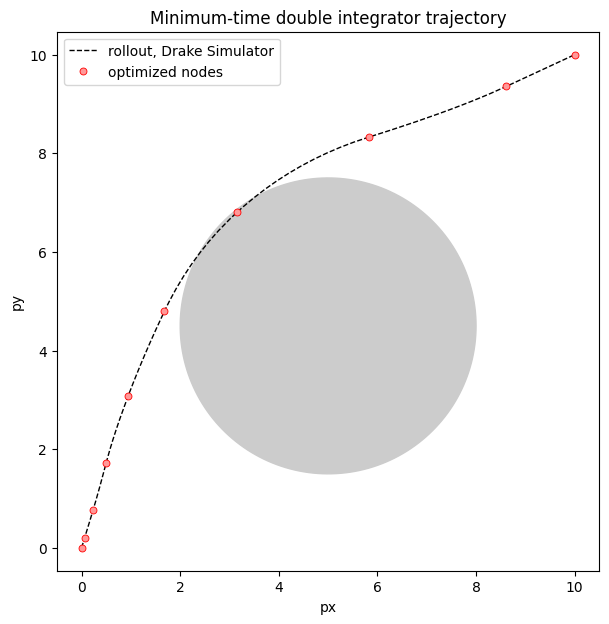

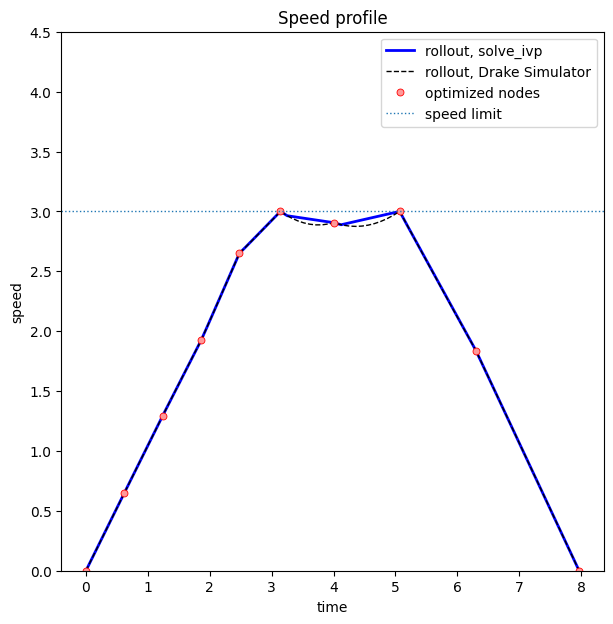

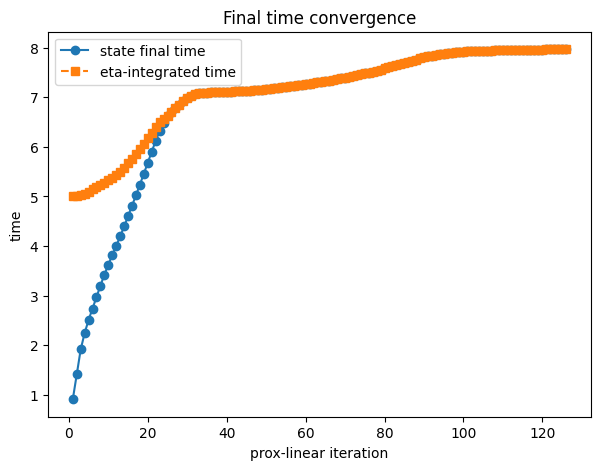

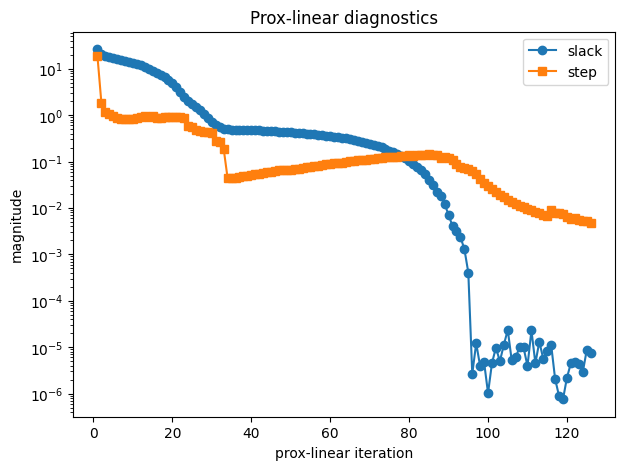

In [8]:

# Run minimum-time prox-linear planning and Drake rollout.
time_problem = make_default_problem()
time_planner = ProxLinearMinimumTimePlanner(
    time_problem,
    random_seed=0,
    verbose=True,
)
time_plan = time_planner.solve()
time_drake_rollout = simulate_plan(time_problem, time_plan)
print_plan_summary(time_problem, time_plan, time_drake_rollout)
plot_results(time_problem, time_plan, drake_rollout=time_drake_rollout)


## Minimum-energy problem

Here the final time is fixed at `tf = 10`, and the last augmented state integrates control energy.

```text
xi  = [px, py, vx, vy, path_violation, energy]
eta = u = [ax, ay]
objective = xi_energy at the final knot
```


### Minimum-energy imports


In [9]:
from __future__ import annotations

from dataclasses import dataclass, field
from typing import List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

from pydrake.solvers import MathematicalProgram, MosekSolver, Solve
from pydrake.systems.analysis import Simulator
from pydrake.systems.framework import BasicVector, DiagramBuilder, LeafSystem
from pydrake.systems.primitives import LogVectorOutput


### Minimum-energy problem data


In [10]:
# Problem data

@dataclass
class MinimumEnergyDoubleIntegratorProblem:
    """All parameters for the 2D double-integrator minimum-energy problem."""

    nx: int = 4
    nu: int = 2
    N: int = 12
    tf: float = 10.0

    x0hat: np.ndarray = field(default_factory=lambda: np.zeros(4))
    xfhat: np.ndarray = field(default_factory=lambda: np.array([10.0, 10.0, 0.0, 0.0]))

    umax: np.ndarray = field(default_factory=lambda: 3.0 * np.ones(2))
    umin: np.ndarray = field(default_factory=lambda: -3.0 * np.ones(2))
    velmax: float = 2.0
    obst_cen: np.ndarray = field(default_factory=lambda: np.array([5.0, 4.5]))
    obst_rad: float = 3.0

    maxiter: int = 1000
    eps: float = 5e-3
    gam: float = 1e1
    rho: Optional[float] = None
    eps_path: float = 1e-6

    ode_rtol: float = 1e-3
    ode_atol: float = 1e-6

    def __post_init__(self) -> None:
        self.nxi = self.nx + 2
        self.neta = self.nu
        self.tstamps = np.linspace(0.0, self.tf, self.N)
        self.dt = self.tf / (self.N - 1)

        self.Ac = np.block(
            [
                [np.zeros((2, 2)), np.eye(2)],
                [np.zeros((2, 2)), np.zeros((2, 2))],
            ]
        )
        self.Bc = np.block([[np.zeros((2, 2))], [np.eye(2)]])
        self.xbar2pos = np.block([np.eye(2), np.zeros((2, 2)), np.zeros((2, 2))])
        self.xbar2vel = np.block([np.zeros((2, 2)), np.eye(2), np.zeros((2, 2))])

        self.x0hat = np.asarray(self.x0hat, dtype=float).reshape(self.nx)
        self.xfhat = np.asarray(self.xfhat, dtype=float).reshape(self.nx)
        self.umax = np.asarray(self.umax, dtype=float).reshape(self.nu)
        self.umin = np.asarray(self.umin, dtype=float).reshape(self.nu)
        self.obst_cen = np.asarray(self.obst_cen, dtype=float).reshape(2)
        self.rho = 1.0 / self.gam if self.rho is None else float(self.rho)


@dataclass
class ProxLinearIterationStats:
    iteration: int
    energy_state: float
    slack: float
    step: float
    solver_name: str
    success: bool


@dataclass
class MinimumEnergyPlan:
    xi_nodes: np.ndarray
    eta_intervals: np.ndarray
    time_grid: np.ndarray
    history: List[ProxLinearIterationStats]

    @property
    def x_nodes(self) -> np.ndarray:
        return self.xi_nodes[:4, :]

    @property
    def violation_nodes(self) -> np.ndarray:
        return self.xi_nodes[4, :]

    @property
    def energy_nodes(self) -> np.ndarray:
        return self.xi_nodes[5, :]

    @property
    def u_intervals(self) -> np.ndarray:
        return self.eta_intervals

    @property
    def final_time(self) -> float:
        return float(self.time_grid[-1])

    @property
    def final_energy(self) -> float:
        return float(self.energy_nodes[-1])


@dataclass
class RolloutLog:
    t: np.ndarray
    x: np.ndarray


### Minimum-energy Drake Systems: plant and feedforward controller


In [11]:
# Drake Systems: physical plant and feedforward controller


class DoubleIntegrator2D(LeafSystem):

    def __init__(self, problem: MinimumEnergyDoubleIntegratorProblem):
        super().__init__()
        self._problem = problem
        self.DeclareVectorInputPort("u", BasicVector(problem.nu))
        self.DeclareContinuousState(problem.nx)
        self.DeclareVectorOutputPort("x", BasicVector(problem.nx), self._calc_output)

    def _calc_output(self, context, output) -> None:
        x = context.get_continuous_state_vector().CopyToVector()
        output.SetFromVector(x)

    def DoCalcTimeDerivatives(self, context, derivatives) -> None:
        x = context.get_continuous_state_vector().CopyToVector()
        u = self.get_input_port(0).Eval(context)
        xdot = self._problem.Ac @ x + self._problem.Bc @ u
        derivatives.get_mutable_vector().SetFromVector(xdot)


class PiecewiseConstantFeedforwardController(LeafSystem):
    """A Drake System wrapping the optimized piecewise-constant u(t)."""

    def __init__(self, break_times: np.ndarray, u_intervals: np.ndarray):
        super().__init__()
        self._break_times = np.asarray(break_times, dtype=float).reshape(-1)
        self._u_intervals = np.asarray(u_intervals, dtype=float)
        assert self._u_intervals.shape[1] == len(self._break_times) - 1
        self.DeclareVectorOutputPort(
            "u", BasicVector(self._u_intervals.shape[0]), self._calc_output
        )

    def _calc_output(self, context, output) -> None:
        t = context.get_time()
        k = int(np.searchsorted(self._break_times, t, side="right") - 1)
        k = int(np.clip(k, 0, self._u_intervals.shape[1] - 1))
        output.SetFromVector(self._u_intervals[:, k])


### Minimum-energy augmented dynamics and flow-map linearization


In [12]:
# Augmented dynamics and exact flow-map linearization


class AugmentedMinimumEnergyDynamics:
    """Augmented dynamics used by the prox-linear planner.

    xi  = [px, py, vx, vy, path_violation_accumulator, energy_accumulator]
    eta = u = [ax, ay]

    dxi/dt = [Ac x + Bc u; path_violation(x); 0.5 * ||u||^2]
    """

    def __init__(self, problem: MinimumEnergyDoubleIntegratorProblem):
        self.p = problem

    def path_violation(self, xi: np.ndarray) -> float:
        vel = self.p.xbar2vel @ xi
        pos = self.p.xbar2pos @ xi
        speed_violation = float(np.dot(vel, vel) / self.p.velmax**2 - 1.0)
        obstacle_violation = float(
            1.0 - np.dot(pos - self.p.obst_cen, pos - self.p.obst_cen) / self.p.obst_rad**2
        )
        return 0.5 * max(speed_violation, 0.0) ** 2 + 0.5 * max(obstacle_violation, 0.0) ** 2

    def fbar(self, xi: np.ndarray, eta: np.ndarray) -> np.ndarray:
        x = xi[: self.p.nx]
        u = eta[: self.p.nu]
        xdot = self.p.Ac @ x + self.p.Bc @ u
        g = self.path_violation(xi)
        energy_dot = 0.5 * float(np.dot(u, u))
        return np.concatenate([xdot, np.array([g, energy_dot])])

    def continuous_jacobians(self, xi: np.ndarray, eta: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """
        dfbar/dxi and dfbar/du.
        """

        u = eta[: self.p.nu]
        vel = self.p.xbar2vel @ xi
        pos = self.p.xbar2pos @ xi
        speed_hinge_arg = np.dot(vel, vel) / self.p.velmax**2 - 1.0
        obstacle_hinge_arg = (
            1.0 - np.dot(pos - self.p.obst_cen, pos - self.p.obst_cen) / self.p.obst_rad**2
        )

        speed_row = (
            (speed_hinge_arg > 0.0)
            * (1.0 / self.p.velmax**2)
            * (vel.reshape(1, 2) @ self.p.xbar2vel)
        )
        obstacle_row = (
            (obstacle_hinge_arg > 0.0)
            * (-(1.0 / self.p.obst_rad**2))
            * ((pos - self.p.obst_cen).reshape(1, 2) @ self.p.xbar2pos)
        )
        violation_row = speed_row + obstacle_row

        top = np.hstack([self.p.Ac, np.zeros((self.p.nx, 2))])
        energy_row = np.zeros((1, self.p.nxi))
        df_dxi = np.vstack([top, violation_row, energy_row])

        # MATLAB: PfbarPu = [Bc; zeros(1,nu); u'].
        df_du = np.vstack([self.p.Bc, np.zeros((1, self.p.nu)), u.reshape(1, self.p.nu)])
        return df_dxi, df_du


class FlowMapLinearizer:
    """Compute xi_{k+1} = F_k(xi_k, u_k) and its Jacobians.
    """

    def __init__(self, problem: MinimumEnergyDoubleIntegratorProblem):
        self.p = problem
        self.dyn = AugmentedMinimumEnergyDynamics(problem)

    def _pack(self, eta: np.ndarray, xi: np.ndarray, Phi_x: np.ndarray, Phi_eta: np.ndarray) -> np.ndarray:
        return np.concatenate(
            [
                eta.reshape(-1),
                xi.reshape(-1),
                Phi_x.reshape(-1, order="F"),
                Phi_eta.reshape(-1, order="F"),
            ]
        )

    def _unpack(self, y: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        p = self.p
        i0 = 0
        i1 = p.neta
        i2 = i1 + p.nxi
        i3 = i2 + p.nxi * p.nxi
        i4 = i3 + p.nxi * p.neta
        eta = y[i0:i1]
        xi = y[i1:i2]
        Phi_x = y[i2:i3].reshape((p.nxi, p.nxi), order="F")
        Phi_eta = y[i3:i4].reshape((p.nxi, p.neta), order="F")
        return eta, xi, Phi_x, Phi_eta

    def _ode(self, _t: float, y: np.ndarray) -> np.ndarray:
        eta, xi, Phi_x, Phi_eta = self._unpack(y)
        df_dxi, df_deta = self.dyn.continuous_jacobians(xi, eta)
        eta_dot = np.zeros(self.p.neta)
        xi_dot = self.dyn.fbar(xi, eta)
        Phi_x_dot = df_dxi @ Phi_x
        Phi_eta_dot = df_dxi @ Phi_eta + df_deta
        return self._pack(eta_dot, xi_dot, Phi_x_dot, Phi_eta_dot)

    def linearize_interval(
        self, xi_nom: np.ndarray, eta_nom: np.ndarray, t0: float, t1: float
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        p = self.p
        y0 = self._pack(
            eta_nom,
            xi_nom,
            np.eye(p.nxi),
            np.zeros((p.nxi, p.neta)),
        )
        sol = solve_ivp(
            self._ode,
            (float(t0), float(t1)),
            y0,
            method="RK45",
            rtol=p.ode_rtol,
            atol=p.ode_atol,
        )
        if not sol.success:
            raise RuntimeError(f"Flow-map integration failed: {sol.message}")

        eta_end, xi_next, A, B = self._unpack(sol.y[:, -1])
        del eta_end  # eta is constant over each interval.
        c = xi_next - A @ xi_nom - B @ eta_nom
        return xi_next, A, B, c


### Minimum-energy prox-linear planner


In [13]:
# optimizer


class ProxLinearMinimumEnergyPlanner:
    """Offline prox-linear trajectory optimizer.

    This class is deliberately not a LeafSystem.  It solves for a plan before
    simulation.  The resulting plan is then wrapped as a feedforward controller.
    """

    def __init__(
        self,
        problem: MinimumEnergyDoubleIntegratorProblem,
        random_seed: Optional[int] = None,
        verbose: bool = True,
    ):
        self.p = problem
        self.random_seed = random_seed
        self.verbose = verbose
        self.linearizer = FlowMapLinearizer(problem)

    def _initialize_nominal(self) -> Tuple[np.ndarray, np.ndarray]:
        p = self.p
        rng = np.random.default_rng(self.random_seed)

        # xi_tilde = rand(nx+2, N), eta_tilde = rand(nu, N-1).
        xi_tilde = rng.random((p.nxi, p.N))
        eta_tilde = rng.random((p.neta, p.N - 1))

        # structured initialization:
        # xi_tilde = np.zeros((p.nxi, p.N))
        # alpha = np.linspace(0.0, 1.0, p.N)
        # for k, a in enumerate(alpha):
        #     xi_tilde[: p.nx, k] = (1.0 - a) * p.x0hat + a * p.xfhat
        # eta_tilde = np.zeros((p.neta, p.N - 1))

        return xi_tilde, eta_tilde

    def _linearize_all(self, xi_tilde: np.ndarray, eta_tilde: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        p = self.p
        A = np.zeros((p.nxi, p.nxi, p.N - 1))
        B = np.zeros((p.nxi, p.neta, p.N - 1))
        c = np.zeros((p.nxi, p.N - 1))
        for k in range(p.N - 1):
            _, A[:, :, k], B[:, :, k], c[:, k] = self.linearizer.linearize_interval(
                xi_tilde[:, k], eta_tilde[:, k], p.tstamps[k], p.tstamps[k + 1]
            )
        return A, B, c

    @staticmethod
    def _solver_name(result) -> str:
        try:
            return result.get_solver_id().name()
        except Exception:
            return "unknown"

    def _solve_subproblem(
        self, xi_tilde: np.ndarray, eta_tilde: np.ndarray, A: np.ndarray, B: np.ndarray, c: np.ndarray
    ):
        p = self.p
        prog = MathematicalProgram()

        Xi = prog.NewContinuousVariables(p.nxi, p.N, "xi")
        Eta = prog.NewContinuousVariables(p.neta, p.N - 1, "eta")
        q = prog.NewContinuousVariables(p.nxi, p.N - 1, "q")
        r = prog.NewContinuousVariables(p.nxi, p.N - 1, "r")

        # Boundary conditions
        prog.AddLinearEqualityConstraint(
            Xi[:, 0], np.concatenate([p.x0hat, np.zeros(2)])
        )
        prog.AddLinearEqualityConstraint(Xi[: p.nx, p.N - 1], p.xfhat)

        # Nonnegative dynamics relaxation slacks q,r
        prog.AddBoundingBoxConstraint(0.0, np.inf, q)
        prog.AddBoundingBoxConstraint(0.0, np.inf, r)

        for k in range(p.N - 1):
            affine_flow = A[:, :, k] @ Xi[:, k] + B[:, :, k] @ Eta[:, k] + c[:, k]
            dyn_residual = Xi[:, k + 1] - affine_flow - q[:, k] + r[:, k]
            prog.AddLinearEqualityConstraint(dyn_residual, np.zeros(p.nxi))

            prog.AddBoundingBoxConstraint(p.umin, p.umax, Eta[:, k])
            prog.AddLinearConstraint(Xi[p.nx, k + 1], -np.inf, p.eps_path)

            # norm(xbar2vel*xi(:,k+1)) <= velmax.
            # In this problem, that is sqrt(vx^2+vy^2) <= velmax.
            prog.AddLorentzConeConstraint(
                np.array([p.velmax, Xi[2, k + 1], Xi[3, k + 1]], dtype=object)
            )

        # Objective: accumulated energy + exact penalty + prox regularization.
        prog.AddLinearCost(Xi[-1, -1])
        prog.AddLinearCost(p.gam * np.sum(q + r))

        xi_vars = Xi.reshape(-1, order="F")
        eta_vars = Eta.reshape(-1, order="F")
        xi_nom = xi_tilde.reshape(-1, order="F")
        eta_nom = eta_tilde.reshape(-1, order="F")

        prog.AddQuadraticErrorCost(
            (0.5 / p.rho) * np.eye(xi_vars.size),
            xi_nom,
            xi_vars,
        )
        prog.AddQuadraticErrorCost(
            (0.5 / p.rho) * np.eye(eta_vars.size),
            eta_nom,
            eta_vars,
        )

        # Give solvers a warm start when they use it.
        prog.SetInitialGuess(Xi, xi_tilde)
        prog.SetInitialGuess(Eta, eta_tilde)
        prog.SetInitialGuess(q, np.zeros((p.nxi, p.N - 1)))
        prog.SetInitialGuess(r, np.zeros((p.nxi, p.N - 1)))

        mosek = MosekSolver()
        result = mosek.Solve(prog, None, None)
        # result = Solve(prog) # will call solver Clarabel
        
        return prog, result, Xi, Eta, q, r

    def solve(self) -> MinimumEnergyPlan:
        p = self.p
        xi_tilde, eta_tilde = self._initialize_nominal()
        history: List[ProxLinearIterationStats] = []

        xi_opt = xi_tilde.copy()
        eta_opt = eta_tilde.copy()

        for iteration in range(1, p.maxiter + 1):
            A, B, c = self._linearize_all(xi_tilde, eta_tilde)
            prog, result, Xi, Eta, q, r = self._solve_subproblem(xi_tilde, eta_tilde, A, B, c)

            if not result.is_success():
                names = []
                try:
                    names = result.GetInfeasibleConstraintNames(prog, 1e-6)
                except Exception:
                    pass
                raise RuntimeError(
                    "The prox-linear convex subproblem failed at iteration "
                    f"{iteration}. Solver={self._solver_name(result)}. "
                    f"Infeasible constraints: {names}"
                )

            xi_opt = result.GetSolution(Xi)
            eta_opt = result.GetSolution(Eta)
            q_opt = result.GetSolution(q)
            r_opt = result.GetSolution(r)

            slack = float(np.sum(q_opt + r_opt))
            step = float(
                np.sqrt(
                    np.sum((xi_opt - xi_tilde) ** 2) + np.sum((eta_opt - eta_tilde) ** 2)
                )
            )
            stats = ProxLinearIterationStats(
                iteration=iteration,
                energy_state=float(xi_opt[-1, -1]),
                slack=slack,
                step=step,
                solver_name=self._solver_name(result),
                success=True,
            )
            history.append(stats)

            if self.verbose:
                print(
                    f"iteration {iteration}, "
                    f"energy {stats.energy_state:.6f}, "
                    f"slack magnitude {slack:.6f}, step length {step:.6f}, "
                    f"solver {stats.solver_name}"
                )

            if step <= p.eps and slack <= p.eps:
                break

            xi_tilde = xi_opt
            eta_tilde = eta_opt

        return MinimumEnergyPlan(
            xi_nodes=xi_opt,
            eta_intervals=eta_opt,
            time_grid=p.tstamps.copy(),
            history=history,
        )


### Minimum-energy simulation and plotting


In [14]:
# Simulation

def make_diagram(problem: MinimumEnergyDoubleIntegratorProblem, plan: MinimumEnergyPlan):
    builder = DiagramBuilder()
    plant = builder.AddSystem(DoubleIntegrator2D(problem))
    controller = builder.AddSystem(
        PiecewiseConstantFeedforwardController(plan.time_grid, plan.u_intervals)
    )
    builder.Connect(controller.get_output_port(0), plant.get_input_port(0))
    logger = LogVectorOutput(plant.get_output_port(0), builder)
    diagram = builder.Build()
    return diagram, plant, logger


def simulate_plan(problem: MinimumEnergyDoubleIntegratorProblem, plan: MinimumEnergyPlan) -> RolloutLog:
    diagram, plant, logger = make_diagram(problem, plan)
    simulator = Simulator(diagram)
    root_context = simulator.get_mutable_context()
    plant_context = plant.GetMyMutableContextFromRoot(root_context)
    plant_context.SetContinuousState(problem.x0hat)
    simulator.Initialize()
    simulator.AdvanceTo(plan.final_time)
    log = logger.FindLog(root_context)
    return RolloutLog(t=log.sample_times(), x=log.data())


def rollout_like_matlab(problem: MinimumEnergyDoubleIntegratorProblem, plan: MinimumEnergyPlan) -> RolloutLog:
    """A scipy solve_ivp rollout mirroring the final MATLAB ode45 loop.
    """

    xs = [problem.x0hat.copy()]
    ts = [0.0]
    xk = problem.x0hat.copy()
    grid = problem.tstamps
    for k in range(problem.N - 1):
        uk = plan.u_intervals[:, k]

        def ode(_t, x):
            return problem.Ac @ x + problem.Bc @ uk

        sol = solve_ivp(
            ode,
            (grid[k], grid[k + 1]),
            xk,
            method="RK45",
            rtol=problem.ode_rtol,
            atol=problem.ode_atol,
        )
        if not sol.success:
            raise RuntimeError(f"Final rollout integration failed: {sol.message}")
        xs.extend([sol.y[:, j] for j in range(1, sol.y.shape[1])])
        ts.extend([sol.t[j] for j in range(1, sol.t.shape[0])])
        xk = sol.y[:, -1]
    return RolloutLog(t=np.asarray(ts), x=np.asarray(xs).T)


def compute_piecewise_energy(problem: MinimumEnergyDoubleIntegratorProblem, plan: MinimumEnergyPlan) -> float:
    energy = 0.0
    for k in range(problem.N - 1):
        dt = problem.tstamps[k + 1] - problem.tstamps[k]
        u = plan.u_intervals[:, k]
        energy += 0.5 * float(np.dot(u, u)) * dt
    return energy


def plot_results(
    problem: MinimumEnergyDoubleIntegratorProblem,
    plan: MinimumEnergyPlan,
    drake_rollout: Optional[RolloutLog] = None,
    matlab_style_rollout: Optional[RolloutLog] = None,
) -> None:
    if drake_rollout is None:
        drake_rollout = simulate_plan(problem, plan)
    if matlab_style_rollout is None:
        matlab_style_rollout = rollout_like_matlab(problem, plan)

    theta = np.linspace(0.0, 2.0 * np.pi, 200)
    circle_x = problem.obst_cen[0] + problem.obst_rad * np.cos(theta)
    circle_y = problem.obst_cen[1] + problem.obst_rad * np.sin(theta)

    plt.figure(figsize=(7, 7))
    plt.fill(circle_x, circle_y, edgecolor=0.8 * np.ones(3), facecolor=0.8 * np.ones(3), linewidth=1)
    # plt.plot(matlab_style_rollout.x[0, :], matlab_style_rollout.x[1, :], "b", linewidth=2, label="rollout, solve_ivp")
    plt.plot(drake_rollout.x[0, :], drake_rollout.x[1, :], "k--", linewidth=1, label="rollout, Drake Simulator")
    plt.plot(
        plan.x_nodes[0, :],
        plan.x_nodes[1, :],
        "ro",
        markersize=5,
        markeredgewidth=0.6,
        markeredgecolor="red",
        markerfacecolor=(1.0, 0.6, 0.6),
        label="optimized nodes",
    )
    plt.axis("equal")
    plt.xlabel("px")
    plt.ylabel("py")
    plt.title("Minimum-energy double integrator trajectory")
    plt.legend()

    speed_scipy = np.sqrt(np.sum(matlab_style_rollout.x[2:4, :] ** 2, axis=0))
    speed_nodes = np.sqrt(np.sum(plan.x_nodes[2:4, :] ** 2, axis=0))
    speed_drake = np.sqrt(np.sum(drake_rollout.x[2:4, :] ** 2, axis=0))

    plt.figure(figsize=(7, 7))
    plt.plot(matlab_style_rollout.t, speed_scipy, "b", linewidth=2, label="rollout, solve_ivp")
    plt.plot(drake_rollout.t, speed_drake, "k--", linewidth=1, label="rollout, Drake Simulator")
    plt.plot(
        problem.tstamps,
        speed_nodes,
        "ro",
        markersize=5,
        markeredgewidth=0.6,
        markeredgecolor="red",
        markerfacecolor=(1.0, 0.6, 0.6),
        label="optimized nodes",
    )
    plt.axhline(problem.velmax, linestyle=":", linewidth=1, label="speed limit")
    plt.ylim([0.0, 1.5 * problem.velmax])
    plt.xlabel("time")
    plt.ylabel("speed")
    plt.title("Speed profile")
    plt.legend()

    if plan.history:
        iters = np.array([h.iteration for h in plan.history])
        energies = np.array([h.energy_state for h in plan.history])
        slacks = np.array([h.slack for h in plan.history])
        steps = np.array([h.step for h in plan.history])

        plt.figure(figsize=(7, 5))
        plt.plot(iters, energies, "o-", label="accumulated energy state")
        plt.xlabel("prox-linear iteration")
        plt.ylabel("energy")
        plt.title("Energy convergence")
        plt.legend()

        plt.figure(figsize=(7, 5))
        plt.semilogy(iters, np.maximum(slacks, 1e-16), "o-", label="slack")
        plt.semilogy(iters, np.maximum(steps, 1e-16), "s-", label="step")
        plt.xlabel("prox-linear iteration")
        plt.ylabel("magnitude")
        plt.title("Prox-linear diagnostics")
        plt.legend()

    plt.show()


def print_plan_summary(problem: MinimumEnergyDoubleIntegratorProblem, plan: MinimumEnergyPlan, rollout: RolloutLog) -> None:
    print("\n=== Minimum-energy plan summary ===")
    print(f"iterations: {len(plan.history)}")
    print(f"fixed final time: {plan.final_time:.8f}")
    print(f"final accumulated energy xi[5,-1]: {plan.final_energy:.8f}")
    print(f"piecewise-constant energy integral: {compute_piecewise_energy(problem, plan):.8f}")
    print(f"final accumulated path violation xi[4,-1]: {plan.violation_nodes[-1]:.8e}")
    print("\nOptimized interval controls u_k, one column per shooting interval:")
    print(plan.u_intervals)
    print("\nFinal rollout state:")
    print(rollout.x[:, -1])
    print("Target final state:")
    print(problem.xfhat)


### Minimum-energy helper `main()` definitions


In [15]:
# helper
def make_default_problem() -> MinimumEnergyDoubleIntegratorProblem:
    return MinimumEnergyDoubleIntegratorProblem()


### Run the minimum-energy example

iteration 1, energy 0.531424, slack magnitude 20.267080, step length 14.435324, solver MOSEK
iteration 2, energy 0.485634, slack magnitude 15.784036, step length 1.559689, solver MOSEK
iteration 3, energy 0.803757, slack magnitude 14.572324, step length 1.182544, solver MOSEK
iteration 4, energy 1.211770, slack magnitude 13.743040, step length 0.944176, solver MOSEK
iteration 5, energy 1.537894, slack magnitude 13.002964, step length 0.839544, solver MOSEK
iteration 6, energy 1.831743, slack magnitude 12.383156, step length 0.771506, solver MOSEK
iteration 7, energy 2.101494, slack magnitude 11.738943, step length 0.783621, solver MOSEK
iteration 8, energy 2.338955, slack magnitude 11.171738, step length 0.719391, solver MOSEK
iteration 9, energy 2.551045, slack magnitude 10.691687, step length 0.681296, solver MOSEK
iteration 10, energy 2.712637, slack magnitude 10.219344, step length 0.664182, solver MOSEK
iteration 11, energy 2.719796, slack magnitude 9.817464, step length 0.623334,

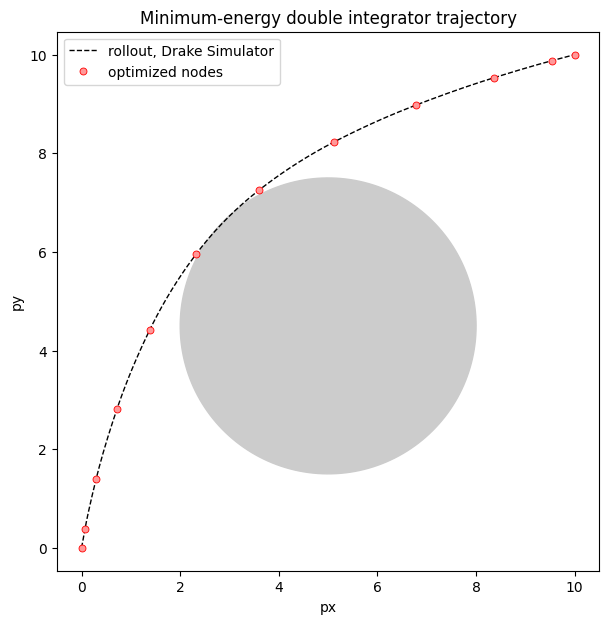

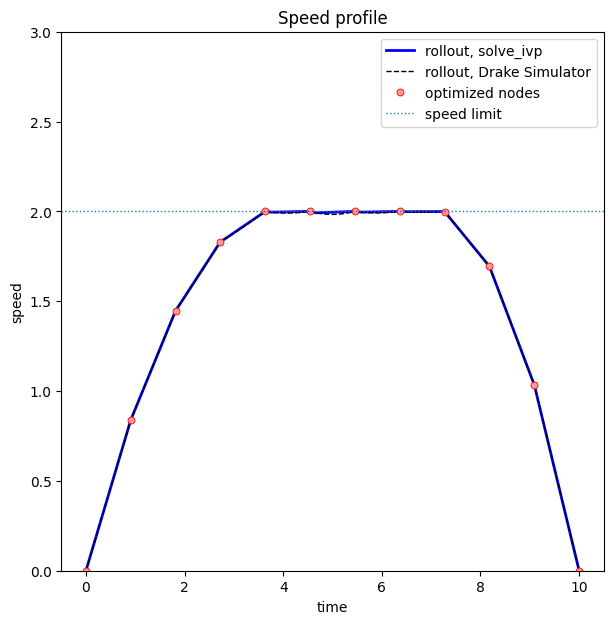

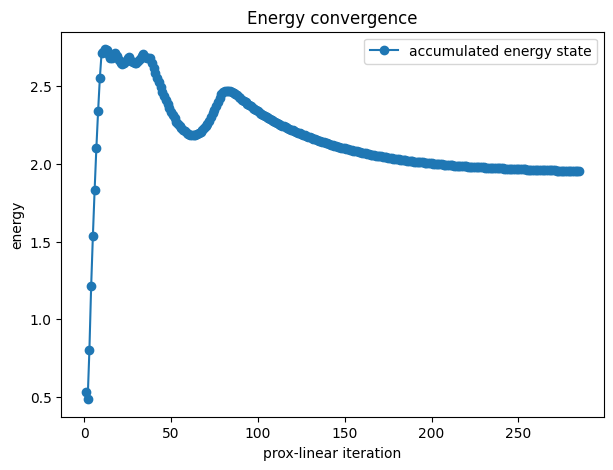

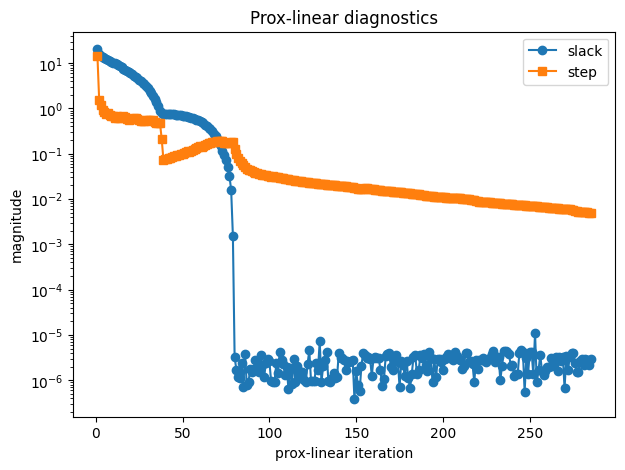

In [16]:

# Run minimum-energy prox-linear planning and Drake rollout
energy_problem = make_default_problem()
energy_planner = ProxLinearMinimumEnergyPlanner(
    energy_problem,
    random_seed=0,
    verbose=True,
)
energy_plan = energy_planner.solve()
energy_drake_rollout = simulate_plan(energy_problem, energy_plan)
print_plan_summary(energy_problem, energy_plan, energy_drake_rollout)
plot_results(energy_problem, energy_plan, drake_rollout=energy_drake_rollout)


The optimizer lives outside the Drake simulation loop. It produces a plan first. The plan is then wrapped as a feedforward `LeafSystem`, connected to the double-integrator `LeafSystem`, logged, and rolled out by `Simulator`.

```text
offline:  Problem -> Planner -> Plan
online:   Plan -> Controller -> Plant -> Logger -> Simulator
```
